### seaborn.kdeplot

`kdeplot` plots univariate or bivariate distributions using kernel density estimation.<br/>

**KDE** (Kernel Density Estimation) is a method for visualizing the distribution of observations in a dataset, analogous to a histogram.

<pre style="font-family:'Courier New';font-size:1.0em;">
<span style="color:orange;font-weight:600;">sns</span>.<span style="color:darkblue;font-weight:600;">kdeplot</span>(
    data,        # input data structure
    x,           # variables that specify
    y,           # positions on the x and y axes.
    hue          # semantic variable that is mapped to determine the color of plot elements.
    weights,     # weight the KDE using these values
    palette,     # method for choosing the colors to use when mapping the <b>hue</b> semantic.
    bw_adjust,   # multiplicatively scales the value chosen by bw_method.Increase to make curve smoother.
    cut,         # how far the grid extends past the extreme datapoints.Set to 0 to truncate at the data limits.
    multiple,    # the method for drawing multiple elements when semantic mapping creates subsets.
    cumulative,  # [True]: estimate a cumulative distribution function.
    common_norm, # [False]: normalize each density independently.
    common_grid ,# [True]:use the same evaluation grid for each kernel density estimate.
    log_scale,   # sets axis scale(s) to log.
    palette,     # method for choosing colors, when mapping the hue semantic.
)
</pre>

While KDE produces a probability distribution, the height of the curve at each point gives a **density**, not a probability. The probability can be obtained by integrating the density across a range.

### Examples

#### Plot a univariate distribution along the x-axis:

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
def format_axis():
    plt.grid(axis="both", c="white")
    plt.gca().set_facecolor("#EAEAF2")
    plt.gca().set_axisbelow(True)

    # Hide the lines denoting the data area boundaries.
    for _, spine in plt.gca().spines.items():
        spine.set_visible(False)

    plt.show()

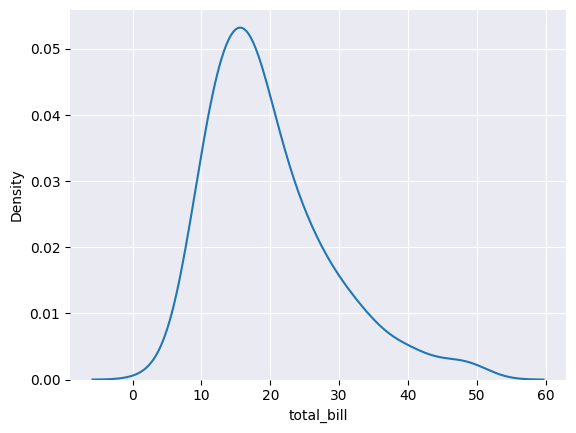

In [5]:
sns.kdeplot(data=tips, x="total_bill")

format_axis()

#### Flip the plot by assigning the data variable to the y-axis

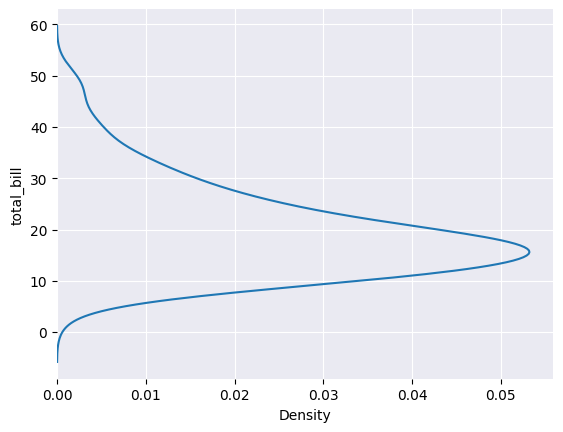

In [76]:
sns.kdeplot(data=tips, y="total_bill")

format_axis()

#### Plot distributions for each column of a wide-form dataset:

In [6]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


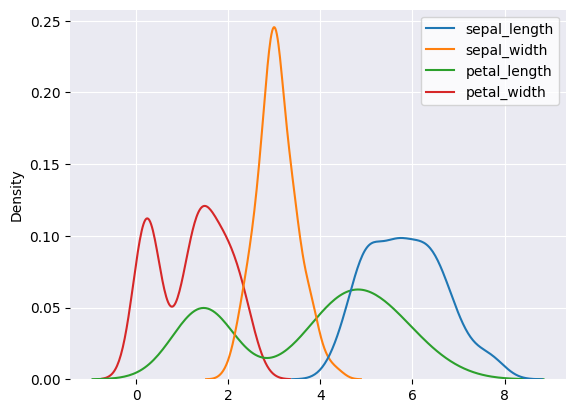

In [7]:
sns.kdeplot(data=iris)
format_axis()

#### Use less smoothing

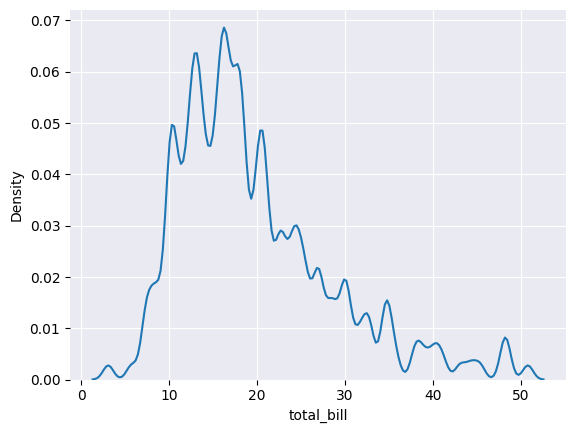

In [79]:
sns.kdeplot(data=tips, x="total_bill", bw_adjust=0.2)
format_axis()

#### Use more smoothing, but don't smooth past the extreme data points.

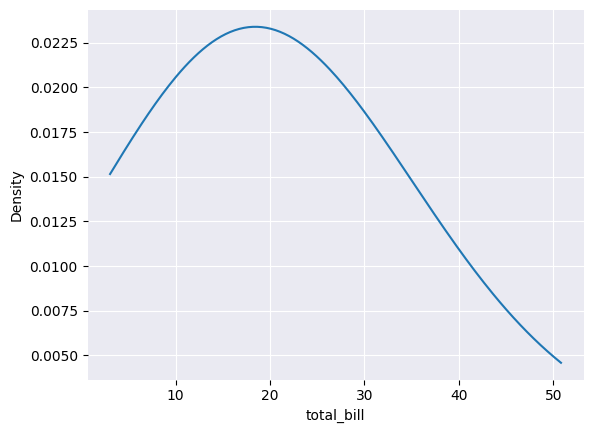

In [80]:
# Increase bandwidth adjust, to make curve smoother.
# Truncate the curve at the data limits.
sns.kdeplot(data=tips, x="total_bill", bw_adjust=5, cut=0)
format_axis()

#### Plot conditional distributions with `hue` mapping of a second variable.

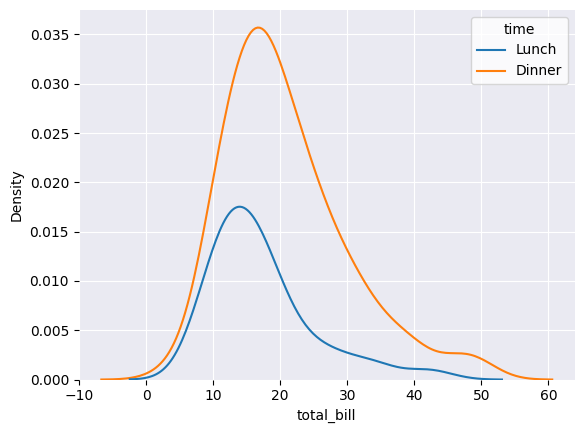

In [81]:
sns.kdeplot(data=tips, x="total_bill", hue="time")
format_axis()

#### **Stack** the conditional distributions:

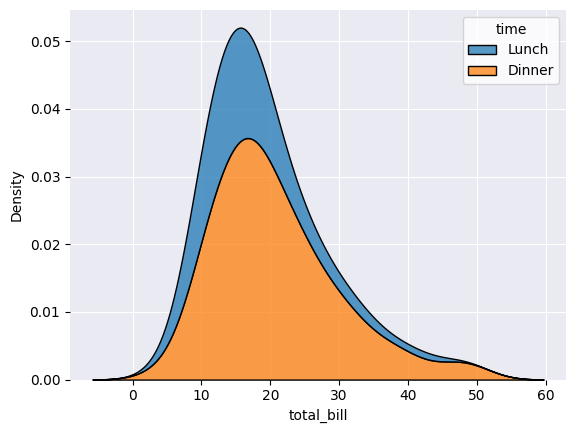

In [82]:
sns.kdeplot(data=tips, x="total_bill", hue="time", multiple="stack")
format_axis()

#### Normalize the stacked distribution at each value in the grid:

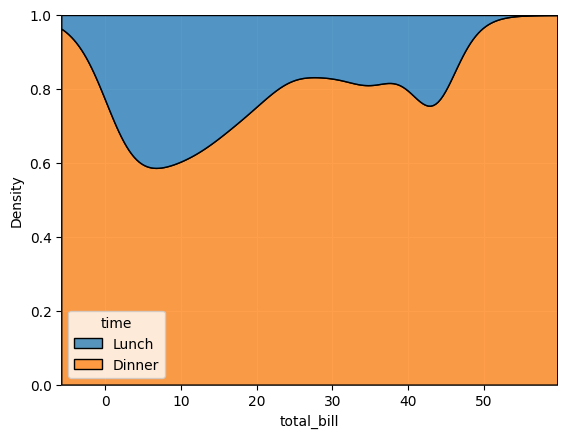

In [83]:
sns.kdeplot(data=tips, x="total_bill", hue="time", multiple="fill")

format_axis()

#### Estimate the cumulative distribution function(s), normalizing each subset:

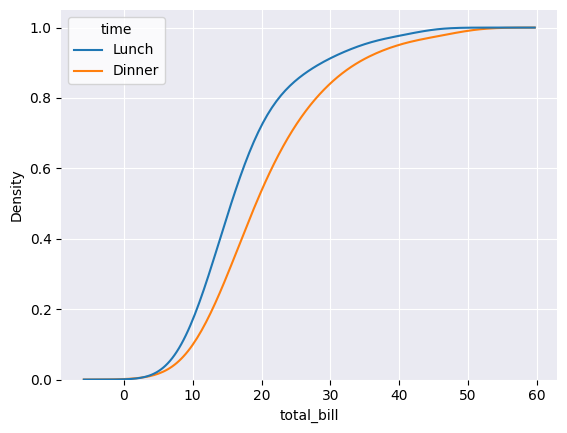

In [84]:
sns.kdeplot(data=tips, x="total_bill", hue="time", cumulative=True, common_norm=False, common_grid=True)

format_axis()

#### Estimate distribution from aggregated data, using weights:

In [8]:
# fmt: off
tips_agg = (tips
    .groupby("size") # size ranges from 1-6    
    .agg(total_bill=("total_bill", "mean"), n=("total_bill", "count"))
)

In [9]:
tips_agg

,total_bill,n
size,,
1,7.242500,4
2,16.448013,156
3,23.277632,38
4,28.613514,37
5,30.068000,5
6,34.830000,4


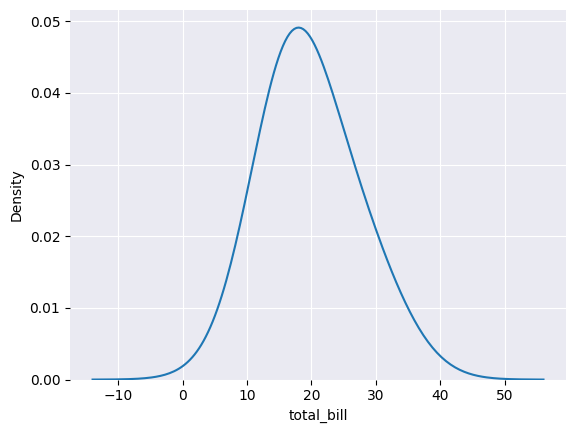

In [10]:
sns.kdeplot(data=tips_agg, x="total_bill", weights="n")
format_axis()

#### Map the data variable with log scaling:

In [101]:
diamonds = sns.load_dataset("diamonds")
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


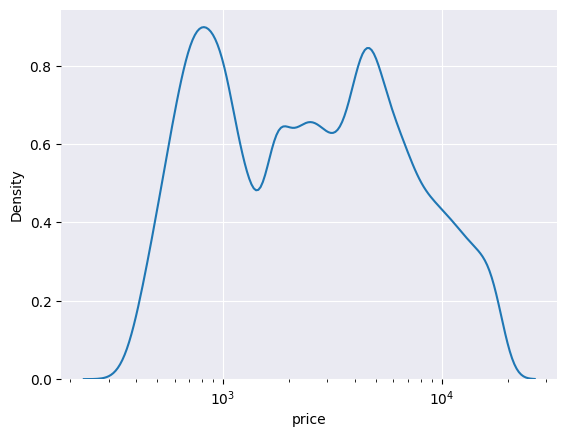

In [102]:
sns.kdeplot(data=diamonds, x="price", log_scale=True)
format_axis()

#### Use numeric hue mapping:

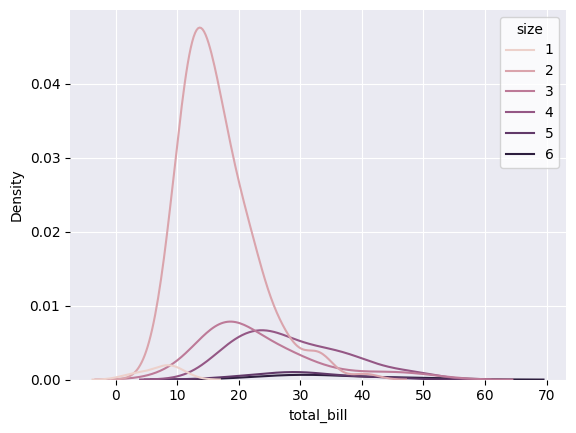

In [103]:
sns.kdeplot(data=tips, x="total_bill", hue="size")
format_axis()

#### Modify the appearance of the plot:

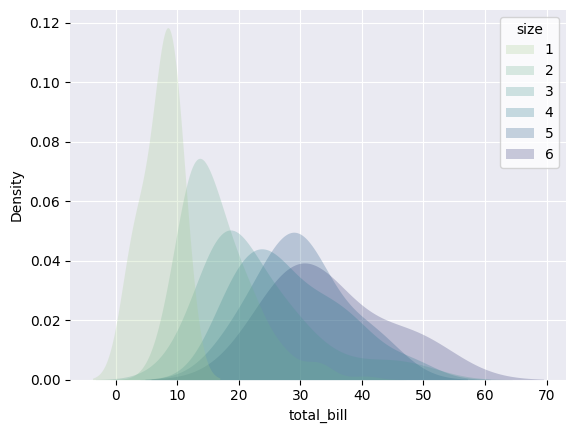

In [109]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="size",
    fill=True,
    common_norm=False,  # normalize each density independently
    palette="crest",
    linewidth=0,
)

format_axis()

#### Plot a bivariate distribution:

In [110]:
geyser = sns.load_dataset("geyser")
geyser

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


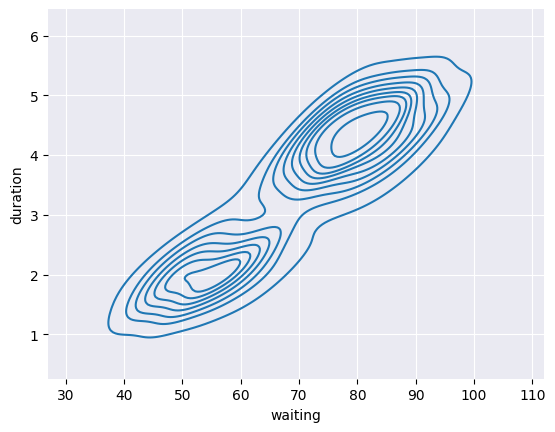

In [111]:
sns.kdeplot(data=geyser, x="waiting", y="duration")
format_axis()

#### Map a third variable with a `hue` semantic to show conditional distributions

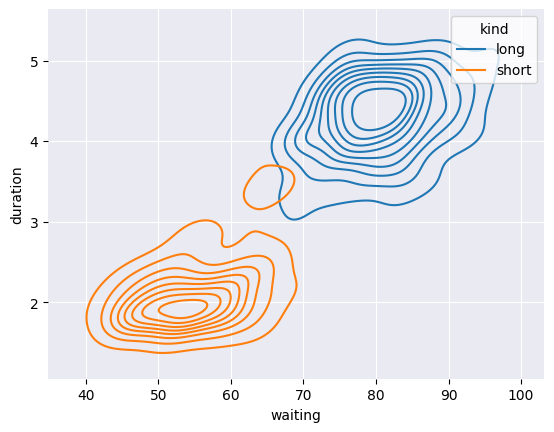

In [112]:
sns.kdeplot(data=geyser, x="waiting", y="duration", hue="kind")
format_axis()

#### Show filled contours:

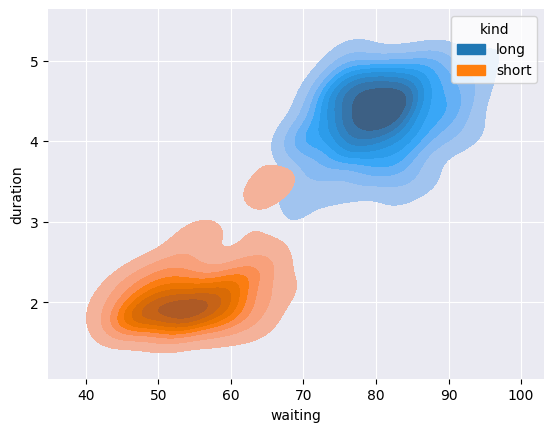

In [113]:
sns.kdeplot(data=geyser, x="waiting", y="duration", hue="kind", fill=True)
format_axis()

#### Show fewer contour levels, covering less of the distribution:

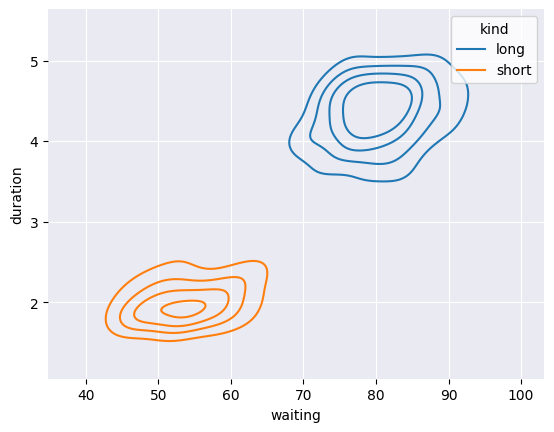

In [114]:
sns.kdeplot(data=geyser, x="waiting", y="duration", hue="kind", levels=5, thresh=0.2)
format_axis()

#### Fill the axes extent with a smooth distribution, using a different colormap:

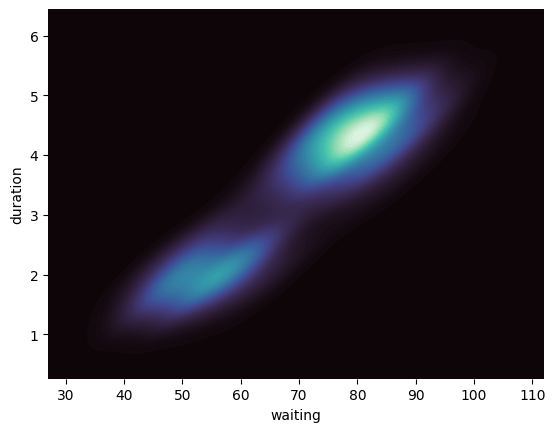

In [118]:
sns.kdeplot(
    data=geyser,
    x="waiting",
    y="duration",
    fill=True,
    thresh=0,
    levels=100,
    cmap="mako",
)
format_axis()